# CAT diagnostics — trial-day exploration
**Partial replication of Prosser et al. (2023), GRL**
*1 July 2016 · North Atlantic (30–60 °N, 75 °W–0 °) · 175 / 200 / 225 hPa · 8 time steps at 3-hourly intervals*

This notebook is a **sanity check**, not a science result — it looks at whether the diagnostics computed by `cat_pipeline.py`
line up with the physics you'd expect on a single day: jet stream in the mid-latitudes, |VWS| and Ellrod TI peaking on
the jet flanks, |PV| tracking the tropopause, and diagnostic hot spots (top 5 %) spatially co-located.

**Prerequisite:** you have already run
```bash
python cat_pipeline.py <your.grib> ./cat_outputs
```
so that `cat_outputs/diagnostics.nc` exists in the same directory as this notebook.

## 0 · Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import LogNorm, SymLogNorm
from IPython.display import HTML, display

# Cartopy is optional — pre-flight test to avoid mid-notebook failures if
# the natural-earth data isn't cached and we can't reach the download URL.
HAS_CARTOPY = False
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import shapereader
    shapereader.natural_earth(resolution="50m", category="physical", name="coastline")
    HAS_CARTOPY = True
except Exception as e:
    print(f"cartopy unavailable ({type(e).__name__}) — maps will render without coastlines")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
np.set_printoptions(suppress=True, precision=4)

OUT = Path("cat_outputs")
ds = xr.open_dataset(OUT / "diagnostics.nc")
print(f"Loaded {len(ds.data_vars)} diagnostics")
print(f"Dimensions: {dict(ds.sizes)}")
print(f"Time steps: {[str(t)[:16] for t in ds.time.values]}")

Loaded 21 diagnostics
Dimensions: {'latitude': 121, 'longitude': 301, 'time': 8}
Time steps: ['2016-07-02T00:00', '2016-07-02T03:00', '2016-07-02T06:00', '2016-07-02T09:00', '2016-07-02T12:00', '2016-07-02T15:00', '2016-07-02T18:00', '2016-07-02T21:00']


## 1 · What's in the file

The 21 diagnostics from Williams & Joshi (2013), collapsed to the 200 hPa target level, kept over the full 8 × 3-hourly
time series and the full lat–lon domain. Native SI units — the pipeline's `comparison_table.csv` handles the conversion
to W&J's table units.

In [2]:
rows = []
for k in ds.data_vars:
    da = ds[k]
    arr = np.asarray(da).ravel()
    arr = arr[np.isfinite(arr)]
    rows.append({
        "diagnostic": k,
        "shape": tuple(da.shape),
        "units": da.attrs.get("units", "?"),
        "median (native)": f"{np.median(arr):+.3g}",
        "p99 (native)":    f"{np.quantile(arr, 0.99):+.3g}",
        "W&J #": da.attrs.get("wj_number", "—"),
    })
pd.DataFrame(rows)

,diagnostic,shape,units,median (native),p99 (native),W&J #
0,magnitude_pv,"(121, 301, 8)",K m**2 kg**-1 s**-1,+3.49e-06,+1.13e-05,1
1,colson_panofsky,"(121, 301, 8)",?,+11.8,+181,2
2,brown1,"(121, 301, 8)",m s**-1,+7.47e-05,+0.000165,3
3,temperature_gradient,"(121, 301, 8)",K,+8.28e-06,+4.35e-05,4
4,horizontal_divergence,"(121, 301, 8)",s**-1,+1.1e-05,+8.73e-05,5
5,vertical_wind_shear,"(121, 301, 8)",?,+0.00423,+0.0139,6
6,endlich,"(121, 301, 8)",m s**-1,+0.00197,+0.00906,7
7,deformation,"(121, 301, 8)",m s**-1,+1.66e-09,+1.92e-08,8
8,wind_speed,"(121, 301, 8)",m s**-1,+20,+49.9,9
9,ngm2,"(121, 301, 8)",m s**-1,+1.14e-07,+7.36e-07,10


## 2 · The upper-level jet, hour by hour

Wind speed at 200 hPa, one panel per time step. Look for:
- a coherent jet stream between roughly **35 °N and 55 °N**,
- meridional meanders (troughs and ridges),
- gentle displacement of features hour to hour — three-hourly steps should show *evolution* not chaos.

If the jet is missing or noise-looking, either the data isn't what you think it is, or the pipeline mis-labelled u/v.

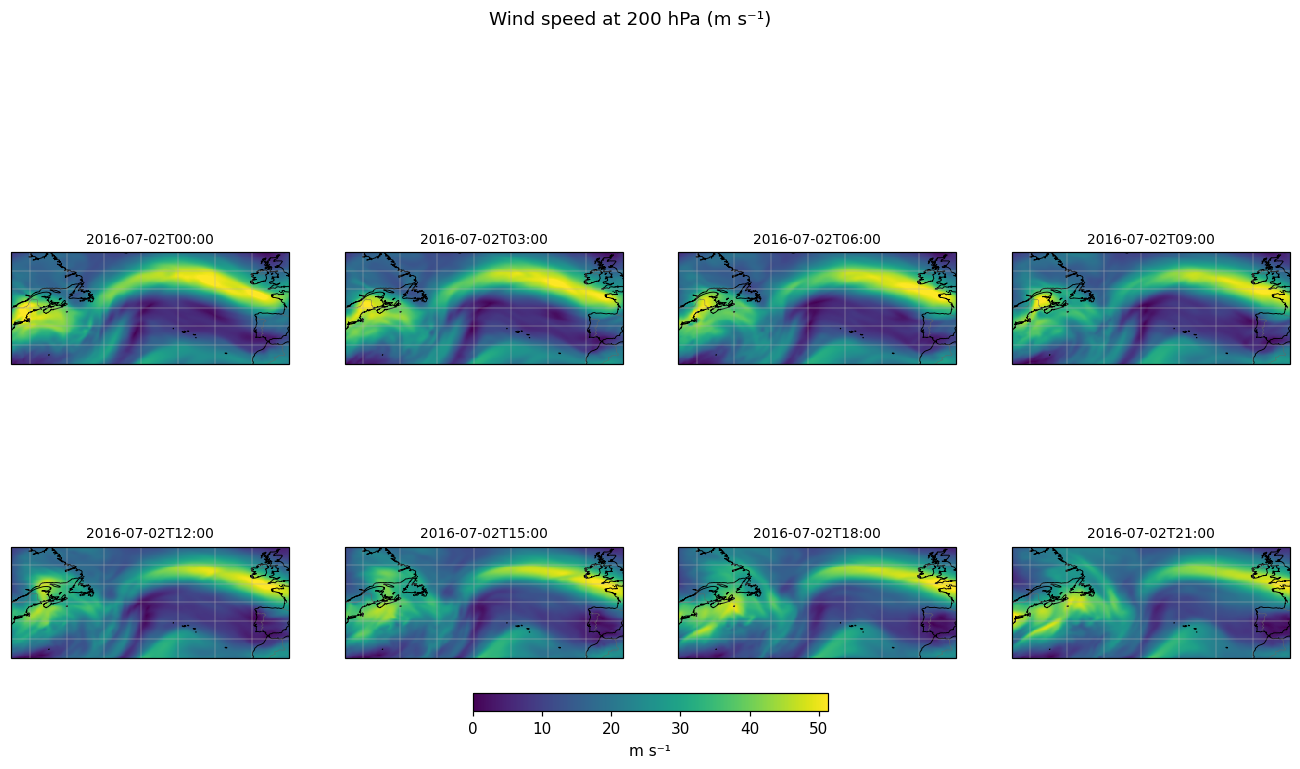

In [3]:
def _add_map_features(ax):
    if HAS_CARTOPY:
        try:
            ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6, edgecolor="k")
            ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.3, edgecolor="0.4")
        except Exception:
            pass  # offline / cartopy data not cached
        ax.set_extent([-75, 0, 30, 60], crs=ccrs.PlateCarree())
        ax.gridlines(draw_labels=False, linewidth=0.3, color="0.7")

def _axes_grid(nrows, ncols, figsize):
    if HAS_CARTOPY:
        proj = ccrs.PlateCarree()
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                                 subplot_kw={"projection": proj})
    else:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    return fig, axes

ws = ds["wind_speed"]                             # (lat, lon, time)
vmin, vmax = 0, float(np.quantile(ws, 0.995))     # symmetric colormap range

fig, axes = _axes_grid(2, 4, figsize=(15, 7))
for i, t in enumerate(ws.time.values):
    ax = axes.flat[i]
    plot_kw = dict(cmap="viridis", vmin=vmin, vmax=vmax, add_colorbar=False)
    if HAS_CARTOPY:
        plot_kw["transform"] = ccrs.PlateCarree()
    ws.sel(time=t).plot.pcolormesh(x="longitude", y="latitude", ax=ax, **plot_kw)
    _add_map_features(ax)
    ax.set_title(str(t)[:16], fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")

fig.suptitle("Wind speed at 200 hPa (m s⁻¹)", y=1.02, fontsize=12)
cb = fig.colorbar(axes.flat[0].collections[0], ax=axes, orientation="horizontal",
                  fraction=0.03, pad=0.06, shrink=0.7)
cb.set_label("m s⁻¹")
plt.show()

## 3 · Time-animated wind speed

Same field, but as a small animation. Renders as JSHTML so it works in the browser without ffmpeg.
Look for **coherent movement** of the jet features between frames — that's the sign your time coordinate is
properly ordered and your GRIB → xarray decode didn't scramble the sequence.

In [4]:
fig, ax = _axes_grid(1, 1, figsize=(9, 5))
if not isinstance(ax, plt.Axes):
    ax = ax                                       # single-axes case

first = ws.isel(time=0)
plot_kw = dict(cmap="viridis", vmin=vmin, vmax=vmax, add_colorbar=True)
if HAS_CARTOPY:
    plot_kw["transform"] = ccrs.PlateCarree()
img = first.plot.pcolormesh(x="longitude", y="latitude", ax=ax, **plot_kw)
_add_map_features(ax)
title = ax.set_title("")

def update(i):
    frame = ws.isel(time=i).values
    img.set_array(frame.ravel())
    title.set_text(f"Wind speed at 200 hPa — {str(ws.time.values[i])[:16]}")
    return [img, title]

anim = animation.FuncAnimation(fig, update, frames=len(ws.time), interval=700, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## 4 · Four CAT diagnostics side by side (day mean)

Time-averaging over the 8 steps to smooth out sub-daily noise. Choose one diagnostic from each family:

| Panel | Diagnostic | What it should highlight |
|---|---|---|
| top-left  | |VWS|      | Jet flanks (vertical wind shear peaks either side of jet core) |
| top-right | DEF (√)    | Deformation zones — stretching + shearing deformation |
| bot-left  | TI1        | Ellrod's original: VWS × DEF → CAT-favourable regions |
| bot-right | |PV|       | Tropopause folding events; high PV = stratospheric intrusion |

The two mechanical diagnostics (VWS, TI1) should show similar structure on the jet flanks. |PV| tells a different
story — it picks out the tropopause dynamic, not the shear.

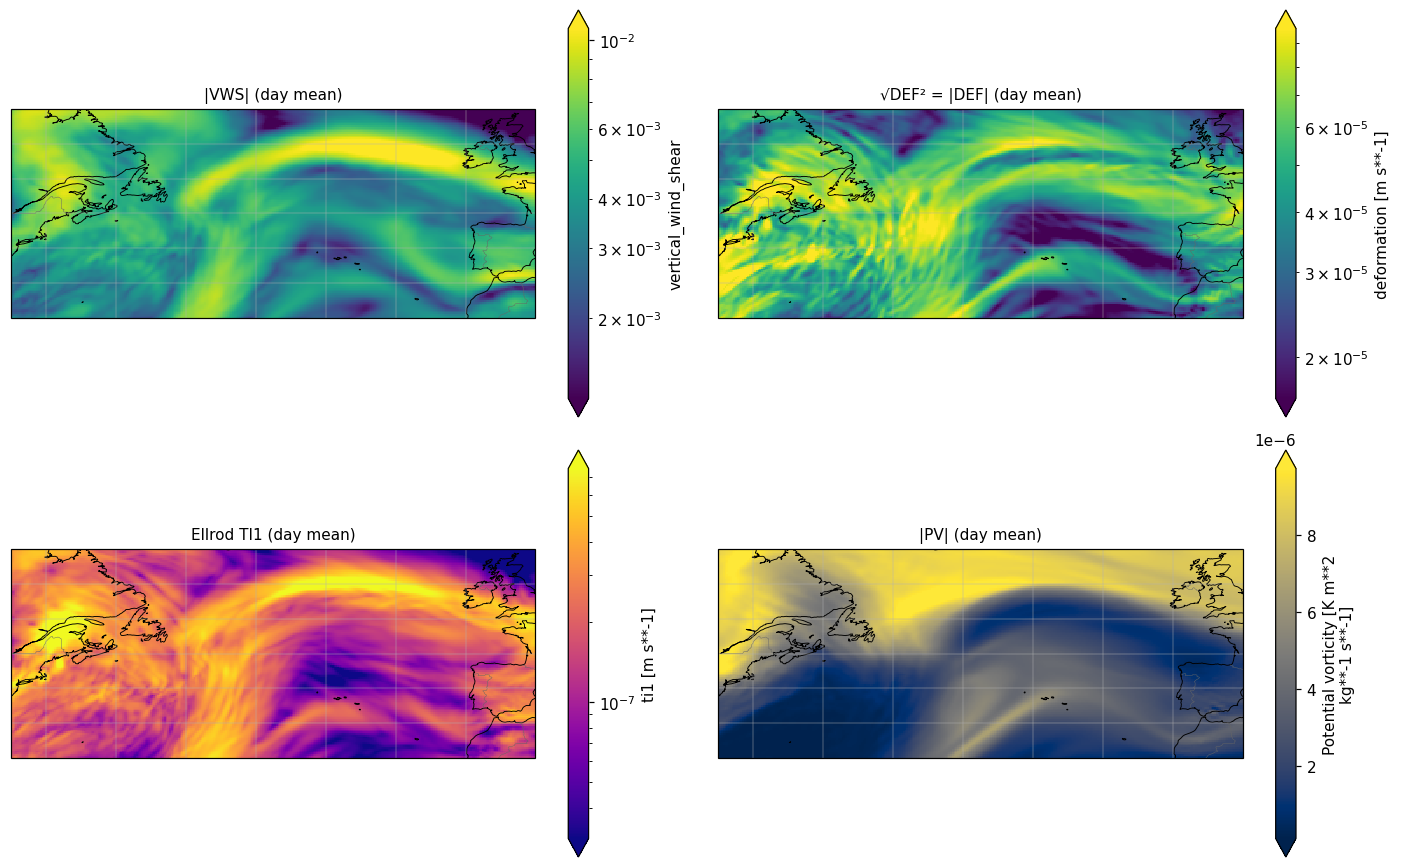

In [5]:
def _plot_panel(ax, da, title, cmap="magma", log=False, sqrt=False):
    vals = da.mean("time")
    if sqrt:
        vals = np.sqrt(np.abs(vals))
    p2, p98 = np.quantile(vals, [0.02, 0.98])
    if log:
        norm = LogNorm(vmin=max(p2, 1e-30), vmax=p98)
        plot_kw = dict(cmap=cmap, norm=norm, add_colorbar=True)
    else:
        plot_kw = dict(cmap=cmap, vmin=p2, vmax=p98, add_colorbar=True)
    if HAS_CARTOPY:
        plot_kw["transform"] = ccrs.PlateCarree()
    vals.plot.pcolormesh(x="longitude", y="latitude", ax=ax, **plot_kw)
    _add_map_features(ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")

fig, axes = _axes_grid(2, 2, figsize=(13, 8))
_plot_panel(axes[0, 0], ds["vertical_wind_shear"], "|VWS| (day mean)", cmap="viridis", log=True)
_plot_panel(axes[0, 1], ds["deformation"],        "√DEF² = |DEF| (day mean)", cmap="viridis", log=True, sqrt=True)
_plot_panel(axes[1, 0], ds["ti1"],                "Ellrod TI1 (day mean)", cmap="plasma", log=True)
_plot_panel(axes[1, 1], ds["magnitude_pv"],       "|PV| (day mean)", cmap="cividis")
plt.tight_layout()
plt.show()

## 5 · Where do the diagnostics agree?

Prosser's approach is inherently rank-based: for each diagnostic, you flag the grid points above some high percentile
threshold. If three shear-based diagnostics all flag the same region, that region is a robust CAT hot spot.

Below: masks of the top-5 % of the day-mean field for four shear-based diagnostics, overlaid. Colour = number of
diagnostics that agree at each grid point. **Dark red = all four flag it.**

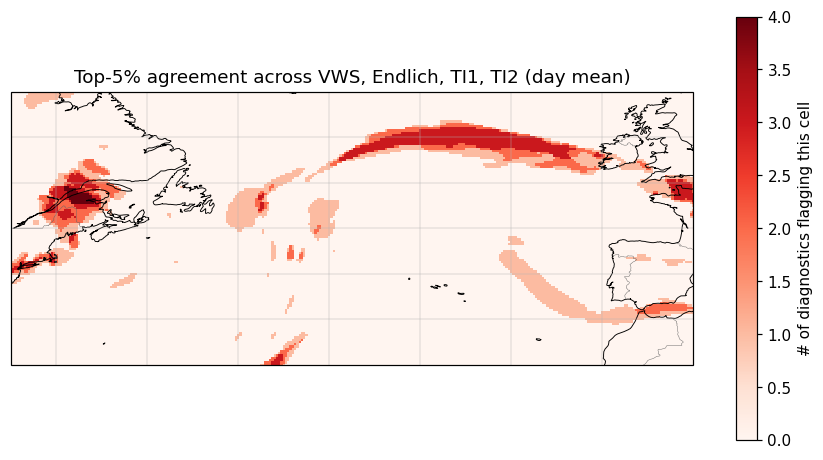


66 / 36421 grid cells (0.2 %) are flagged by ALL 4 shear diagnostics.


In [6]:
picks = ["vertical_wind_shear", "endlich", "ti1", "ti2"]
masks = []
for k in picks:
    daily_mean = ds[k].mean("time")
    thresh = np.quantile(daily_mean, 0.95)
    masks.append((daily_mean > thresh).astype(int))
agreement = sum(masks)  # 0 (none) → 4 (all)

fig, ax = _axes_grid(1, 1, figsize=(10, 5))
plot_kw = dict(cmap="Reds", vmin=0, vmax=len(picks), add_colorbar=True,
               cbar_kwargs={"label": "# of diagnostics flagging this cell"})
if HAS_CARTOPY:
    plot_kw["transform"] = ccrs.PlateCarree()
agreement.plot.pcolormesh(x="longitude", y="latitude", ax=ax, **plot_kw)
_add_map_features(ax)
ax.set_title("Top-5% agreement across VWS, Endlich, TI1, TI2 (day mean)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.show()

n_agree = int((agreement == len(picks)).sum())
n_total = int(agreement.size)
print(f"\n{n_agree} / {n_total} grid cells ({100*n_agree/n_total:.1f} %) are flagged by ALL {len(picks)} shear diagnostics.")

## 6 · Diagnostic distributions

Log-scale PDFs of six representative diagnostics. In principle the tail of each distribution — not the median — is
where turbulence lives; Prosser's percentile-threshold approach uses the 99–99.9 % tails.

For a single day over a modest box, expect heavy-tailed distributions but with long, sparse tails
(the 99.9 %-ile is one grid point in a thousand).

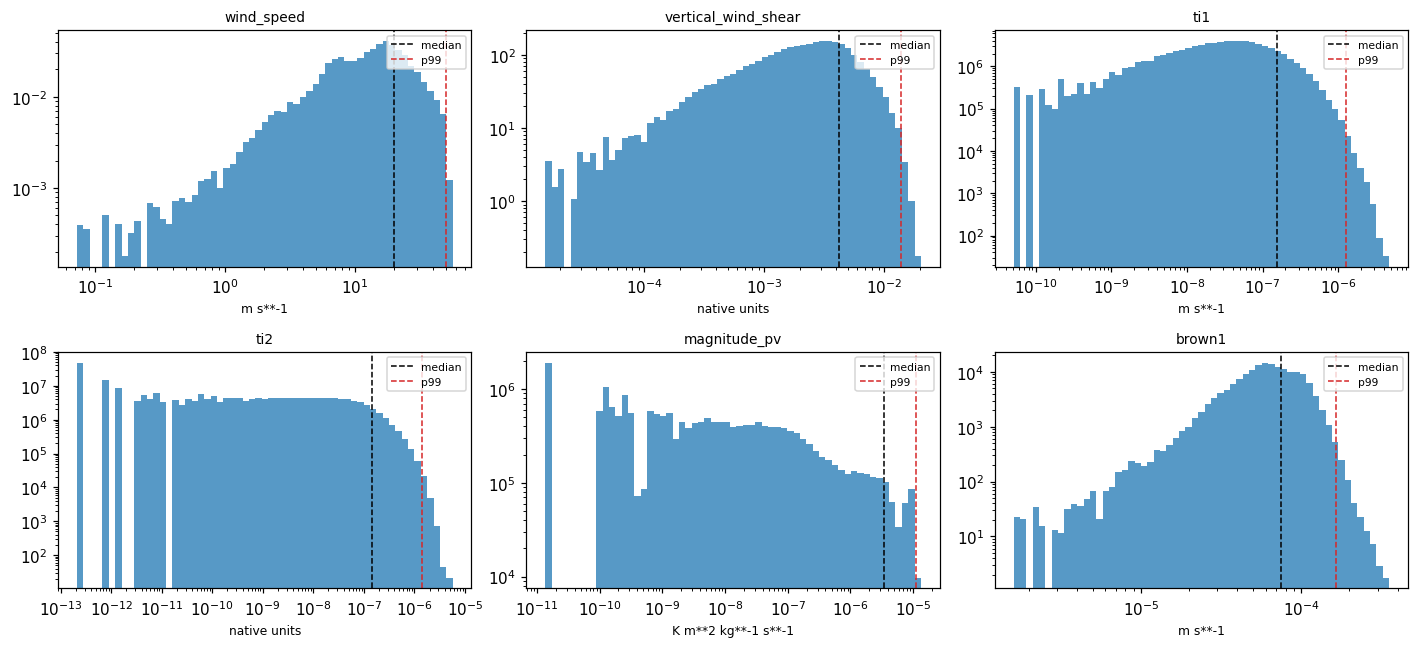

In [7]:
picks = ["wind_speed", "vertical_wind_shear", "ti1", "ti2",
         "magnitude_pv", "brown1"]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, k in zip(axes.flat, picks):
    arr = np.abs(np.asarray(ds[k]).ravel())
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if arr.size == 0:
        ax.set_visible(False); continue
    ax.hist(arr, bins=np.geomspace(arr.min(), arr.max(), 60),
            density=True, alpha=0.75, edgecolor="none")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.axvline(np.median(arr), color="k", ls="--", lw=1, label=f"median")
    ax.axvline(np.quantile(arr, 0.99), color="C3", ls="--", lw=1, label="p99")
    ax.set_title(k, fontsize=9)
    ax.set_xlabel(ds[k].attrs.get("units", "native units"), fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

## 7 · Cross-diagnostic correlation

Spatial correlation between the day-mean fields of every diagnostic. Diagnostics built on the same physical
mechanism should be highly correlated — Ellrod's TI1 and TI2 differ only in their divergence term and typically
correlate at ρ > 0.95. Diagnostics that measure different things (e.g. |PV| vs |VWS|) may correlate weakly or
even negatively.

**Sanity check:** high correlation among the shear-based cluster (VWS, TI1, TI2, NGM1); moderate to high among the
deformation-based (DEF, F2D); |PV| loosely correlated with everything.

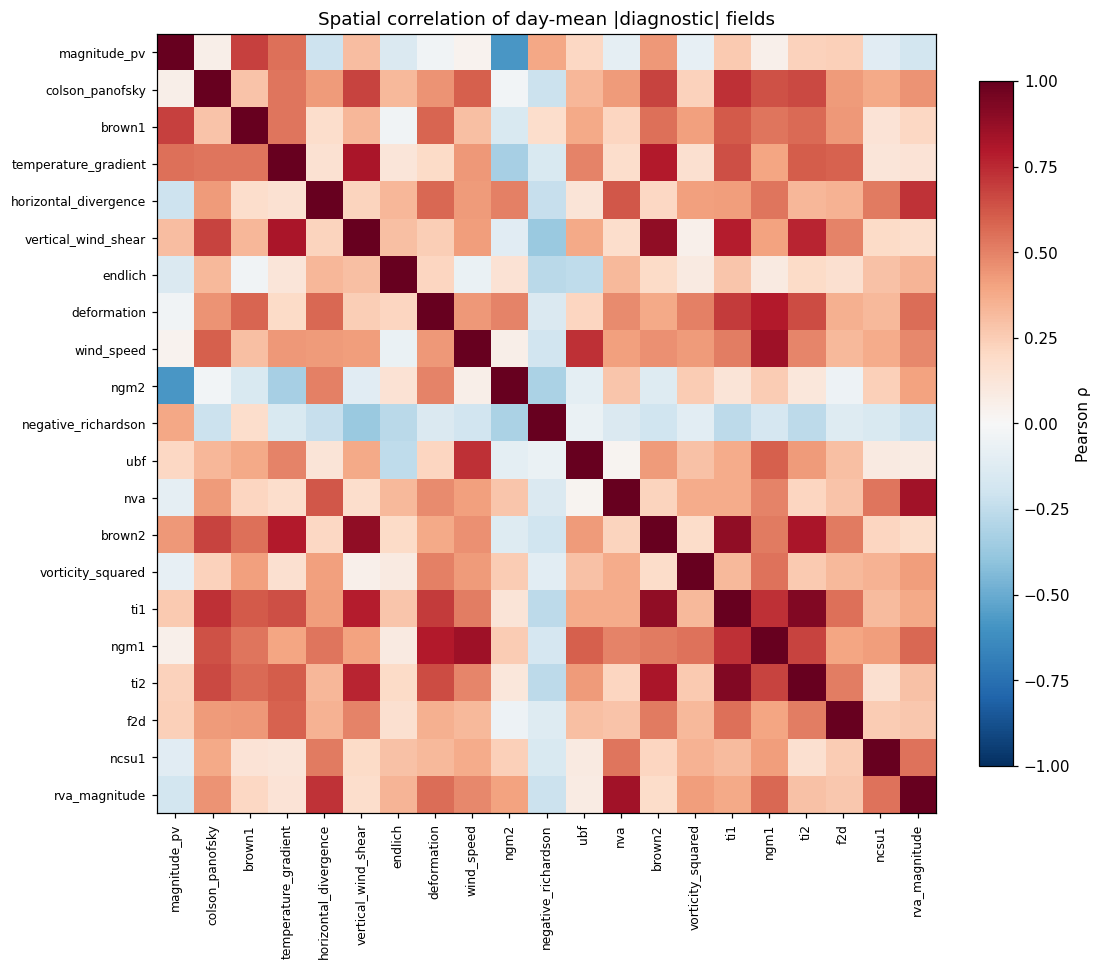

In [8]:
names = list(ds.data_vars)
flat = np.stack([np.abs(ds[n].mean("time")).values.ravel() for n in names])
# Drop rows that are all-NaN or all-zero
valid = np.array([np.isfinite(row).any() and np.nanstd(row) > 0 for row in flat])
flat, names = flat[valid], [n for n, v in zip(names, valid) if v]
# Handle NaNs (a few may leak from edge-of-domain gradients)
flat = np.where(np.isfinite(flat), flat, np.nan)
corr = np.corrcoef(np.ma.masked_invalid(flat))

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_yticklabels(names, fontsize=8)
ax.set_title("Spatial correlation of day-mean |diagnostic| fields")
plt.colorbar(im, ax=ax, fraction=0.04, label="Pearson ρ")
plt.tight_layout()
plt.show()

## 8 · Comparison against Williams & Joshi (2013), Table 1

Reloading the CSV that `cat_pipeline.py` already wrote. Order-of-magnitude comparison of trial medians and p99s
against W&J's climate-model medians.

In [9]:
comp = pd.read_csv(OUT / "comparison_table.csv")
comp

,#,Diagnostic,W&J units,W&J median,Trial median (table units),Trial p99 (table units),Status
0,1,Magnitude of potential vorticity,PVU,6.840,3.490000e+00,1.130000e+01,PLAUSIBLE
1,2,Colson–Panofsky index,10^3 kt^2,-34.800,1.180000e+01,1.810000e+02,PLAUSIBLE
2,3,Brown index,10^-6 s^-1,77.100,7.470000e+01,1.650000e+02,PLAUSIBLE
3,4,|Horizontal temperature gradient|,10^-6 K m^-1,5.750,8.280000e+00,4.350000e+01,PLAUSIBLE
4,5,|Horizontal divergence|,10^-6 s^-1,2.820,1.100000e+01,8.730000e+01,PLAUSIBLE
5,6,|Vertical wind shear|,10^-3 s^-1,1.880,4.230000e+00,1.390000e+01,PLAUSIBLE
6,7,Wind speed × directional shear,10^-3 rad s^-1,0.952,1.970000e+00,9.060000e+00,PLAUSIBLE
7,8,Flow deformation (rojak returns squared),10^-6 s^-1,18.600,4.070000e+01,1.380000e+02,PLAUSIBLE
8,9,Wind speed,m s^-1,14.900,2.000000e+01,4.990000e+01,PLAUSIBLE
9,10,Deformation × vertical T gradient,10^-9 K m^-1 s^-1,8.170,1.140000e+02,7.360000e+02,1-2 ORDERS OFF


### What to do with this

- **PLAUSIBLE** rows: pipeline is producing values in the right ballpark for this one day. Nothing more to do.
- **1–2 ORDERS OFF** rows: on a single day over a modest domain, these may look off simply because the domain
  didn't sample a strong event. Recheck once you have a full month.
- **FLAG** rows: cross-reference §6 of `VALIDATION_REPORT.md` — the report calls out exactly which of these are
  synthetic-data artefacts (should resolve on real data) and which are genuine open questions about rojak's
  internal definitions (Brown2 units, Frontogenesis 2D cross term).

Once you're happy with the trial, the natural next step is **one calendar year** — a full month exercises
the CDS pipeline, and a full year exercises the seasonal cycle. See VALIDATION_REPORT.md §8 (Phases 2c–2d)
for the scaling roadmap.